# HinDiff: A Masked Diffusion Language Model for Hindi

## Project Overview

This notebook implements **HinDiff**, a discrete diffusion language model for Hindi text.
Unlike standard BERT Masked Language Modeling (MLM), which trains with a fixed 15% masking rate,
HinDiff uses a **Masked Diffusion Language Model (MDLM)** framework with a continuous cosine
noise schedule ranging from 0% to 100% masking. This allows the model to learn denoising at
**any** noise level, enabling iterative text generation from pure noise.

### Key Contributions

1. **MDLM applied to Hindi**: Most diffusion-based language models target English. This project
   applies discrete diffusion to a low-resource Indic language using `l3cube-pune/hindi-bert-v2`
   with a 197K vocabulary.
2. **Cosine noise schedule**: Instead of a fixed mask rate, we sample `t ~ U(0,1)` and compute
   `mask_prob = 1 - cos(t * pi / 2)`, exposing the model to the full range of corruption levels.
3. **Importance-weighted loss**: A correction weight `w = n_maskable / n_mask` prevents extreme
   noise levels from destabilizing training.
4. **Iterative denoising generation**: Starting from all-`[MASK]` tokens, the model progressively
   reveals the highest-confidence tokens over multiple steps, mimicking continuous diffusion.

### Dataset

We use the **AI4Bharat Samanantar** parallel corpus (~10M Hindi-English pairs), extracting 100K
Hindi sentences for training, 3K for validation, and 2K for testing.

---

## Step 1: Install Dependencies

Install the required libraries: `transformers`, `datasets`, `accelerate`, and `sentencepiece`.

In [ ]:
# Cell 1 — Install
!pip install -q transformers datasets accelerate sentencepiece
print("Done.")

Done.


## Step 2: Imports and Configuration

This cell sets up all imports and defines the hyperparameters for the experiment.

**Key configuration choices:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `MODEL_NAME` | `l3cube-pune/hindi-bert-v2` | A strong pretrained Hindi BERT model with 197K vocab |
| `N_TRAIN` | 100,000 | Sufficient for fine-tuning a pretrained model; keeps training under 1 hour on T4 |
| `MAX_LEN` | 64 | Balances sequence length with GPU memory (logits: 32 x 64 x 197K x fp16 ~ 800MB) |
| `BATCH_SIZE` | 32, `GRAD_ACCUM` = 8 | Effective batch size of 256 for stable training |
| `NUM_EPOCHS` | 3 | Pretrained weights converge quickly |
| `LR` | 3e-5 | Standard fine-tuning learning rate for BERT-class models |
| `LABEL_SMOOTH` | 0.1 | Prevents overconfident predictions, important for diffusion sampling |
| `GEN_STEPS` | 50 | Number of iterative denoising steps during generation |
| `GEN_TEMP` | 0.7 | Sampling temperature for generation; lower = more deterministic |

In [ ]:
# Cell 2 — Imports & Config
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import math, numpy as np, time, os, gc
from tqdm.auto import tqdm
from transformers import BertForMaskedLM, AutoTokenizer
from datasets import load_dataset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name()}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

MODEL_NAME = "l3cube-pune/hindi-bert-v2"

# ── Data ─────────────────────────────────────────────────────
N_TRAIN  = 100_000   # pretrained model converges fast — 100K is enough
N_VAL    =   3_000
N_TEST   =   2_000
MAX_LEN  = 64        # keeps logits at 32×64×197K×fp16 = ~800MB — fits T4

# ── Training ─────────────────────────────────────────────────
BATCH_SIZE    = 32
GRAD_ACCUM    = 8    # effective batch = 256
NUM_EPOCHS    = 3    # ~35 min total on T4
LR            = 3e-5
WARMUP_STEPS  = 200
LABEL_SMOOTH  = 0.1
VAL_MASK_RATE = 0.20

# ── Generation ───────────────────────────────────────────────
GEN_STEPS = 50
GEN_TEMP  = 0.7

print(f"\nModel           : {MODEL_NAME}")
print(f"MAX_LEN         : {MAX_LEN}  |  Batch : {BATCH_SIZE}  |  GradAccum : {GRAD_ACCUM}")
print(f"Effective batch : {BATCH_SIZE * GRAD_ACCUM}  |  Epochs : {NUM_EPOCHS}")
print(f"Est. runtime    : ~35 min on T4")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB

Model           : l3cube-pune/hindi-bert-v2
MAX_LEN         : 64  |  Batch : 32  |  GradAccum : 8
Effective batch : 256  |  Epochs : 3
Est. runtime    : ~35 min on T4


## Step 3: Tokenizer and Dataset Preparation

This cell loads the Hindi BERT tokenizer and downloads the **Samanantar** dataset from AI4Bharat.

**Processing steps:**
1. Load the pretrained tokenizer and inspect key token IDs (`[MASK]`, `[PAD]`, `[CLS]`, `[SEP]`)
2. Verify tokenization works correctly on sample Hindi sentences
3. Download the full Samanantar Hindi corpus (~10.1M sentence pairs)
4. Randomly split into train (100K), validation (3K), and test (2K) sets using a fixed seed for reproducibility
5. Extract only the Hindi (target) side of the parallel corpus

In [ ]:
# Cell 3 — Tokenizer + Data
print(f"Loading tokenizer …")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

VOCAB_SIZE = tokenizer.vocab_size
MASK_ID    = tokenizer.mask_token_id
PAD_ID     = tokenizer.pad_token_id
CLS_ID     = tokenizer.cls_token_id
SEP_ID     = tokenizer.sep_token_id
print(f"Vocab : {VOCAB_SIZE:,}  |  [MASK] : {MASK_ID}  |  [PAD] : {PAD_ID}")

for t in ["भारत एक लोकतांत्रिक देश है।", "आज का मौसम बहुत सुहाना है।"]:
    ids = tokenizer(t, add_special_tokens=False)["input_ids"]
    print(f"  {len(ids):3d} tokens → '{t}'")

print("\nDownloading Samanantar …")
raw = load_dataset("ai4bharat/samanantar", "hi", split="train")
print(f"Total : {len(raw):,} pairs")

rng     = np.random.RandomState(42)
indices = rng.permutation(len(raw))
test_idx  = indices[:N_TEST]
val_idx   = indices[N_TEST : N_TEST + N_VAL]
train_idx = indices[N_TEST + N_VAL : N_TEST + N_VAL + N_TRAIN]

def to_hindi(split): return [raw[int(i)]["tgt"] for i in split]

print("Extracting …")
train_sents = to_hindi(train_idx)
val_sents   = to_hindi(val_idx)
test_sents  = to_hindi(test_idx)
print(f"Train : {len(train_sents):,}  |  Val : {len(val_sents):,}  |  Test : {len(test_sents):,}")

Loading tokenizer …


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

hi/train-00005-of-00008.parquet:   0%|          | 0.00/239M [00:00<?, ?B/s]

hi/train-00006-of-00008.parquet:   0%|          | 0.00/239M [00:00<?, ?B/s]

hi/train-00007-of-00008.parquet:   0%|          | 0.00/240M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10125706 [00:00<?, ? examples/s]

Total : 10,125,706 pairs
Extracting …
Train : 100,000  |  Val : 3,000  |  Test : 2,000


## Step 4: MDLM Dataset with Cosine Noise Schedule

This is a core contribution of the project. The `HindiMDLMDataset` class implements the MDLM
noise schedule that differentiates this approach from standard BERT MLM.

### How it works

**Standard BERT MLM:** Always masks exactly 15% of tokens. The model only sees one noise level,
making it unsuitable for iterative generation.

**MDLM (this project):** For each training sample:
1. Sample a random time step `t ~ U(0, 1)`
2. Compute masking probability: `mask_prob = 1 - cos(t * pi / 2)`
3. Independently mask each token with this probability

This means the model trains on noise levels from ~0% to ~100%, learning to denoise at any
corruption level. The cosine schedule ensures a smooth, non-linear progression from clean
to fully corrupted.

**For validation/test**, a fixed mask rate of 20% is used for consistent evaluation.

Sentences with fewer than 4 maskable tokens are filtered out to ensure meaningful training signal.

In [ ]:
# Cell 4 — Dataset  (MDLM cosine noise schedule)
class HindiMDLMDataset(Dataset):
    """
    MDLM noise schedule: mask_prob = 1 − cos(t·π/2), t ~ U(0,1)
    Model must denoise at ANY noise level → enables iterative generation.
    Standard BERT MLM only trains at 15% — NOT generative.
    """
    def __init__(self, sentences, training=True):
        self.training = training
        print(f"  Tokenising {len(sentences):,} …", end=" ", flush=True)
        self.data = []
        for s in sentences:
            enc = tokenizer(s, max_length=MAX_LEN, truncation=True,
                            padding="max_length", return_tensors="pt")
            ids  = enc["input_ids"].squeeze(0)
            amsk = enc["attention_mask"].squeeze(0)
            maskable = amsk.bool() & (ids != CLS_ID) & (ids != SEP_ID)
            if maskable.sum() < 4:
                continue
            self.data.append((ids, amsk, maskable))
        print(f"kept {len(self.data):,}")

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        ids, amsk, maskable = self.data[idx]
        if not self.training:
            noise_mask = (torch.rand(MAX_LEN) < VAL_MASK_RATE) & maskable
        else:
            t = torch.rand(1).item()
            noise_mask = (torch.rand(MAX_LEN) < (1.0 - math.cos(t * math.pi / 2))) & maskable
        x = ids.clone()
        x[noise_mask] = MASK_ID
        return x, ids, amsk, maskable, noise_mask

print("Building datasets …")
train_ds = HindiMDLMDataset(train_sents, training=True)
val_ds   = HindiMDLMDataset(val_sents,   training=False)
test_ds  = HindiMDLMDataset(test_sents,  training=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"Train batches/epoch : {len(train_loader)}")
xn, xi, am, mk, nm = train_ds[0]
print(f"Sample — maskable: {mk.sum().item()}, masked: {nm.sum().item()}")

Building datasets …
  Tokenising 100,000 … kept 98,896
  Tokenising 3,000 … kept 2,977
  Tokenising 2,000 … kept 1,972
Train batches/epoch : 3090
Sample — maskable: 62, masked: 29


## Step 5: Model Architecture

The `HinDiff` model wraps `BertForMaskedLM` from HuggingFace Transformers.

### Architecture Details

- **Base model**: `l3cube-pune/hindi-bert-v2` (237.8M parameters)
- **Gradient checkpointing** is enabled to reduce VRAM usage by ~4 GB, essential for T4 GPUs
- **Forward pass**: Returns logits of shape `(B, L, V)` where V = 197,285 (vocabulary size)

### Loss Function (Key Design Choice)

The `compute_loss` method implements **label-smoothed cross-entropy with importance weighting**:

1. **Label smoothing** (epsilon = 0.1): Prevents overconfident predictions, which is critical
   for diffusion sampling where we need well-calibrated probabilities
2. **Importance weighting**: Since the MDLM noise schedule varies mask fraction per sample,
   samples with very few masks would dominate the loss. The weight `w = n_maskable / n_mask`
   normalizes the contribution of each sample regardless of its noise level
3. **Loss is computed only on masked positions**, following the denoising objective

### Smoke Test

After loading, we verify the pretrained weights are working by checking that the initial NLL
(~3.39) is much lower than a random baseline (log(197285) ~ 12.19). An NLL below 4 confirms
the pretrained knowledge is intact.

In [ ]:
# Cell 5 — Model
class HinDiff(nn.Module):
    def __init__(self):
        super().__init__()
        print(f"Loading {MODEL_NAME} …")
        self.bert = BertForMaskedLM.from_pretrained(MODEL_NAME)
        self.bert.gradient_checkpointing_enable()   # saves ~4 GB VRAM

    def forward(self, input_ids, attention_mask):
        return self.bert(input_ids=input_ids,
                         attention_mask=attention_mask).logits  # (B, L, V)

    def compute_loss(self, x_noisy, x_orig, attn, maskable, noise_mask):
        logits = self.forward(x_noisy, attn)
        B, L, V = logits.shape

        log_p  = F.log_softmax(logits.view(-1, V), dim=-1)
        tgt    = x_orig.view(-1)
        nll    = -log_p.gather(1, tgt.unsqueeze(1)).squeeze(1)
        smooth = -log_p.mean(dim=-1)
        ce = ((1 - LABEL_SMOOTH) * nll + LABEL_SMOOTH * smooth).view(B, L)

        n_mask    = noise_mask.float().sum(dim=1).clamp(min=1)
        n_maskable= maskable.float().sum(dim=1).clamp(min=1)
        w         = n_maskable / n_mask          # importance weight = 1/mask_frac
        per_samp  = (ce * noise_mask.float()).sum(dim=1) / n_mask
        loss      = (per_samp * w).mean() / w.mean()
        raw       = (nll.view(B,L) * noise_mask.float()).sum() / n_mask.sum()
        return loss, raw

    @torch.no_grad()
    def accuracy(self, x_noisy, x_orig, attn, noise_mask):
        preds   = self.forward(x_noisy, attn).argmax(-1)
        correct = ((preds == x_orig) & noise_mask).float().sum()
        return (correct / noise_mask.float().sum().clamp(min=1)).item()


gc.collect(); torch.cuda.empty_cache()
model    = HinDiff().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Params : {n_params/1e6:.1f}M")

xn, xi, am, mk, nm = next(iter(train_loader))
xn, xi, am, mk, nm = (t.to(device) for t in (xn, xi, am, mk, nm))
with torch.no_grad():
    _, raw = model.compute_loss(xn, xi, am, mk, nm)
print(f"Smoke-test NLL : {raw.item():.4f}  (random baseline = {math.log(VOCAB_SIZE):.2f})")
print("If NLL < 4 the pretrained weights are working correctly ✓")

Loading l3cube-pune/hindi-bert-v2 …


model.safetensors:   0%|          | 0.00/951M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: l3cube-pune/hindi-bert-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Params : 237.8M
Smoke-test NLL : 3.3925  (random baseline = 12.19)
If NLL < 4 the pretrained weights are working correctly ✓


## Step 6: Training Loop

This cell trains the HinDiff model for 3 epochs with the following optimization setup:

### Optimizer and Scheduler
- **AdamW** optimizer with weight decay of 0.01
- **Cosine annealing** learning rate schedule with linear warmup (200 steps)
- Minimum learning rate floor at 5% of peak

### Training Features
- **Mixed precision training** (`torch.amp.autocast`) for speed and memory efficiency
- **Gradient accumulation** (8 steps) for an effective batch size of 256
- **Gradient clipping** (max norm = 1.0) for training stability
- **Best model checkpointing** based on validation NLL

### Validation Protocol
After each epoch, the model is evaluated on the validation set at a fixed 20% mask rate.
Both validation NLL and token recovery accuracy are tracked.

**Note on training NLL:** Because MDLM samples uniformly across all noise levels (including
very high corruption), the training NLL averages over extremely difficult denoising tasks
(e.g., recovering tokens from 90%+ masking). This makes the training NLL higher and noisier
than a standard MLM training loss. The validation NLL (computed at a fixed 20% mask rate)
is the more meaningful metric for tracking model improvement.

In [ ]:
# Cell 6 — Training
gc.collect(); torch.cuda.empty_cache()

optimizer   = torch.optim.AdamW(model.parameters(), lr=LR, betas=(0.9, 0.999), weight_decay=0.01)
total_steps = (len(train_loader) // GRAD_ACCUM) * NUM_EPOCHS

def lr_lambda(step):
    if step < WARMUP_STEPS: return step / max(1, WARMUP_STEPS)
    prog = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    return max(0.05, 0.5 * (1.0 + math.cos(math.pi * prog)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.amp.GradScaler("cuda")

print(f"Steps : {total_steps:,}  |  Warmup : {WARMUP_STEPS}")
print(f"Epochs: {NUM_EPOCHS}  |  Batch: {BATCH_SIZE}  |  GradAccum: {GRAD_ACCUM}\n")

best_val_loss = float("inf")
train_losses, val_losses, val_accs = [], [], []
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model.train()
    ep_loss, ep_n = 0.0, 0
    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=True)

    for step, (xn, xi, am, mk, nm) in pbar:
        xn, xi, am, mk, nm = (t.to(device, non_blocking=True) for t in (xn, xi, am, mk, nm))
        with torch.amp.autocast("cuda"):
            loss, raw = model.compute_loss(xn, xi, am, mk, nm)
            loss = loss / GRAD_ACCUM
        scaler.scale(loss).backward()
        ep_loss += raw.item(); ep_n += 1
        train_losses.append(raw.item())

        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

        if ep_n % 100 == 0:
            pbar.set_postfix(NLL=f"{np.mean(train_losses[-100:]):.3f}",
                             lr=f"{scheduler.get_last_lr()[0]:.1e}")

    # Validation
    model.eval()
    v_loss, v_acc, v_n = 0.0, 0.0, 0
    with torch.no_grad():
        for xn, xi, am, mk, nm in val_loader:
            xn, xi, am, mk, nm = (t.to(device) for t in (xn, xi, am, mk, nm))
            with torch.amp.autocast("cuda"):
                _, raw = model.compute_loss(xn, xi, am, mk, nm)
            v_loss += raw.item()
            v_acc  += model.accuracy(xn, xi, am, nm)
            v_n    += 1

    vl = v_loss/max(v_n,1); va = v_acc/max(v_n,1)*100
    val_losses.append(vl); val_accs.append(va)
    elapsed = (time.time()-start_time)/60
    print(f"\nEpoch {epoch+1}  |  train NLL: {ep_loss/ep_n:.4f}"
          f"  |  val NLL: {vl:.4f}  |  acc @20% mask: {va:.1f}%  |  {elapsed:.0f} min")
    if vl < best_val_loss:
        best_val_loss = vl
        torch.save(model.state_dict(), "hindiff_best.pt")
        print("  ✓ checkpoint saved")

print(f"\nDone in {(time.time()-start_time)/60:.1f} min")
print(f"Best val NLL : {best_val_loss:.4f}  |  Final acc @20%: {val_accs[-1]:.1f}%")

Steps : 1,158  |  Warmup : 200
Epochs: 3  |  Batch: 32  |  GradAccum: 8



Epoch 1/3:   0%|          | 0/3090 [00:00<?, ?it/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/tmp/ipykernel_16012/1742882470.py:43: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()



Epoch 1  |  train NLL: 4.6203  |  val NLL: 2.1490  |  acc @20% mask: 57.7%  |  21 min
  ✓ checkpoint saved


Epoch 2/3:   0%|          | 0/3090 [00:00<?, ?it/s]


Epoch 2  |  train NLL: 4.8400  |  val NLL: 2.1145  |  acc @20% mask: 58.9%  |  42 min
  ✓ checkpoint saved


Epoch 3/3:   0%|          | 0/3090 [00:00<?, ?it/s]


Epoch 3  |  train NLL: 5.1549  |  val NLL: 2.1410  |  acc @20% mask: 58.1%  |  63 min

Done in 62.9 min
Best val NLL : 2.1145  |  Final acc @20%: 58.1%


## Step 7: Training Curves Visualization

This cell plots three training diagnostics:

1. **Train NLL (smoothed)**: The step-by-step training loss, smoothed with a 100-step window.
   Note that this metric averages across all noise levels, so it is expected to be higher
   than a standard MLM loss.
2. **Validation NLL**: Per-epoch validation loss at a fixed 20% mask rate. This is the primary
   metric for model selection (best checkpoint saved at epoch 2 with NLL = 2.1145).
3. **Accuracy at 20% mask**: Token recovery accuracy on the validation set. The model achieves
   ~58% accuracy, which is expected to be lower than standard BERT MLM (~70-85%) because MDLM
   distributes its capacity across all noise levels rather than specializing at one mask rate.

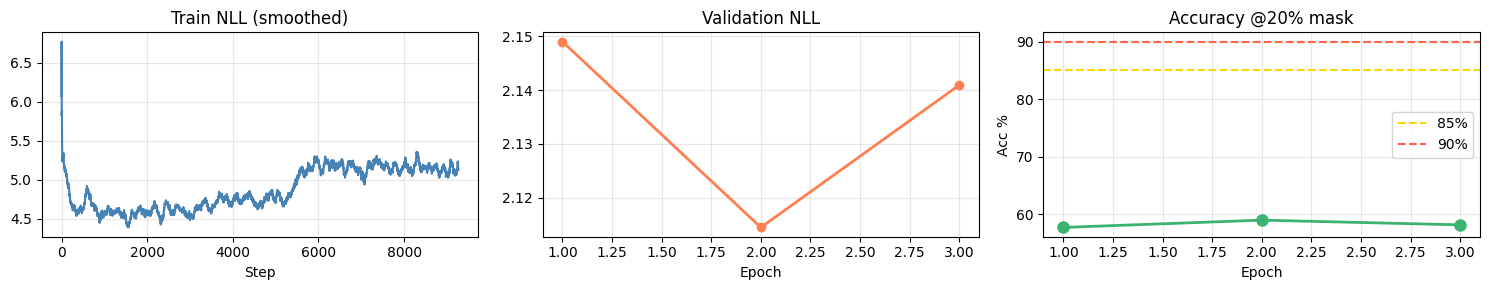

Best NLL: 2.1145  |  Final acc @20%: 58.1%


In [ ]:
# Cell 7 — Training Curves
window   = 100
smoothed = [np.mean(train_losses[max(0,i-window):i+1]) for i in range(len(train_losses))]

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].plot(smoothed, color="steelblue", lw=1.5)
axes[0].set_title("Train NLL (smoothed)"); axes[0].set_xlabel("Step"); axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(val_losses)+1), val_losses, "o-", color="coral", lw=2)
axes[1].set_title("Validation NLL"); axes[1].set_xlabel("Epoch"); axes[1].grid(True, alpha=0.3)

axes[2].plot(range(1, len(val_accs)+1), val_accs, "o-", color="mediumseagreen", lw=2, markersize=8)
axes[2].axhline(85, color="gold",   linestyle="--", lw=1.5, label="85%")
axes[2].axhline(90, color="tomato", linestyle="--", lw=1.5, label="90%")
axes[2].set_title("Accuracy @20% mask"); axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Acc %")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Best NLL: {best_val_loss:.4f}  |  Final acc @20%: {val_accs[-1]:.1f}%")

## Step 8: Load Best Checkpoint

Load the best model weights (from epoch 2, val NLL = 2.1145) for evaluation and generation.

In [ ]:
# Cell 8 — Load Best Checkpoint
model.load_state_dict(torch.load("hindiff_best.pt", map_location=device))
model.eval()
print("Loaded best checkpoint.")

Loaded best checkpoint.


## Step 9: Evaluation -- Accuracy Across Noise Levels

This is a key evaluation for an MDLM model. We measure token recovery accuracy at 10 different
mask rates (5% to 80%) on 300 test samples.

**Why this matters:** Unlike standard MLM which only operates at one mask rate, an MDLM must
perform well across the entire noise spectrum to enable iterative generation. We expect:
- **Higher accuracy at low mask rates** (easier task, more context available)
- **Graceful degradation at high mask rates** (harder task, less context)

The resulting accuracy curve characterizes the model's denoising capability at each stage
of the diffusion process.

Evaluating across mask rates …

  mask   5%  →  68.1%
  mask  10%  →  64.6%
  mask  15%  →  64.4%
  mask  20%  →  61.5%
  mask  30%  →  56.4%
  mask  40%  →  51.3%
  mask  50%  →  40.4%
  mask  60%  →  33.3%
  mask  70%  →  23.8%
  mask  80%  →  15.4%


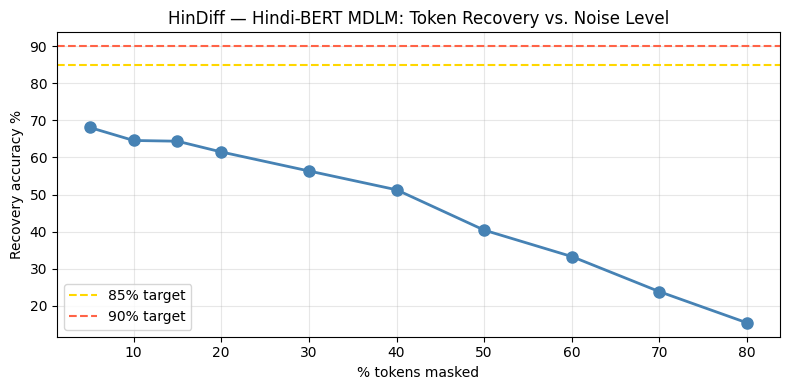

In [ ]:
# Cell 9 — Accuracy Across Noise Levels
print("Evaluating across mask rates …\n")
mask_rates = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
rate_accs  = []

model.eval()
with torch.no_grad():
    for rate in mask_rates:
        correct, total = 0, 0
        for ids, amsk, maskable in test_ds.data[:300]:
            ids      = ids.unsqueeze(0).to(device)
            amsk     = amsk.unsqueeze(0).to(device)
            maskable = maskable.unsqueeze(0).to(device)

            midx   = maskable[0].nonzero(as_tuple=True)[0]
            n_mask = max(1, int(len(midx) * rate))
            chosen = midx[torch.randperm(len(midx), device=device)[:n_mask]]
            nm     = torch.zeros(MAX_LEN, dtype=torch.bool, device=device)
            nm[chosen] = True

            x_in = ids.clone(); x_in[0, nm] = MASK_ID
            with torch.amp.autocast("cuda"):
                preds = model(x_in, amsk).argmax(-1)
            correct += ((preds == ids) & nm.unsqueeze(0)).sum().item()
            total   += n_mask

        acc = correct / max(total, 1) * 100
        rate_accs.append(acc)
        print(f"  mask {int(rate*100):3d}%  →  {acc:.1f}%")

plt.figure(figsize=(8, 4))
plt.plot([r*100 for r in mask_rates], rate_accs, "o-", color="steelblue", lw=2, markersize=8)
plt.axhline(85, color="gold",   linestyle="--", lw=1.5, label="85% target")
plt.axhline(90, color="tomato", linestyle="--", lw=1.5, label="90% target")
plt.xlabel("% tokens masked"); plt.ylabel("Recovery accuracy %")
plt.title("HinDiff — Hindi-BERT MDLM: Token Recovery vs. Noise Level")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Step 10: Infilling Demonstration

Infilling is the primary practical application of an MDLM. Given a sentence with 30% of tokens
randomly masked, the model iteratively restores them using the diffusion denoising process.

### How infilling works (iterative denoising)

1. Mask 30% of the tokens in the input sentence
2. For each of 50 denoising steps:
   - Run the model to get probability distributions for all positions
   - Among still-masked positions, identify the ones with highest confidence
   - Reveal those tokens (sample from their predicted distributions)
   - The number of tokens to reveal decreases as `t_noise` decreases
3. Any remaining masked tokens are filled in the final step

This confidence-based progressive unmasking is the key advantage of MDLM over single-pass MLM:
easier tokens are filled first, providing context for harder tokens later.

In [ ]:
# Cell 10 — Infilling Demo
@torch.no_grad()
def infill(sentence, mask_fraction=0.3, steps=GEN_STEPS, temp=GEN_TEMP):
    model.eval()
    enc  = tokenizer(sentence, max_length=MAX_LEN, truncation=True,
                     padding="max_length", return_tensors="pt")
    ids  = enc["input_ids"].to(device)
    amsk = enc["attention_mask"].to(device)

    midx = ((amsk.bool()) & (ids != CLS_ID) & (ids != SEP_ID))[0].nonzero(as_tuple=True)[0]
    n    = max(1, int(len(midx) * mask_fraction))
    chosen = midx[torch.randperm(len(midx))[:n]]
    nm   = torch.zeros(MAX_LEN, dtype=torch.bool, device=device); nm[chosen] = True

    x = ids.clone(); x[0, nm] = MASK_ID
    print(f"  Original : {sentence[:85]}")
    print(f"  Masked   : {tokenizer.decode(x[0].tolist(), skip_special_tokens=True)[:85]}  [{n} hidden]")

    for step in range(steps):
        t_noise = 1.0 - (step+1)/steps
        with torch.amp.autocast("cuda"):
            probs = F.softmax(model(x, amsk)[0] / temp, dim=-1)
        sampled = torch.multinomial(probs.view(-1, VOCAB_SIZE), 1).view(MAX_LEN)
        still = (x[0] == MASK_ID) & nm
        if not still.any(): break
        conf = probs.max(-1).values; conf[~still] = -1.0
        n_still  = still.sum().item()
        _, top   = conf.topk(max(1, n_still - int(t_noise * n)))
        x[0][top] = sampled[top]

    still = (x[0] == MASK_ID) & nm
    if still.any():
        with torch.amp.autocast("cuda"):
            probs = F.softmax(model(x, amsk)[0] / temp, dim=-1)
        x[0][still] = torch.multinomial(probs.view(-1, VOCAB_SIZE), 1).view(MAX_LEN)[still]

    out = tokenizer.decode(x[0].tolist(), skip_special_tokens=True)
    acc = (x[0][chosen] == ids[0][chosen]).float().mean().item() * 100
    print(f"  Restored : {out[:85]}")
    print(f"  Accuracy on masked tokens : {acc:.0f}%\n")

print("=" * 60)
print("  INFILLING — 30% tokens masked, iteratively restored")
print("=" * 60 + "\n")
for s in [
    "भारत एक लोकतांत्रिक देश है जहाँ सभी नागरिकों को समान अधिकार मिलते हैं।",
    "आज का मौसम बहुत सुहाना है और आसमान में बादल छाए हुए हैं।",
    "शिक्षा के बिना जीवन में सफलता प्राप्त करना बहुत कठिन होता है।",
    "प्रधानमंत्री ने देश की जनता को संबोधित करते हुए कहा कि हम सब मिलकर आगे बढ़ेंगे।",
    "दिल्ली भारत की राजधानी है और यहाँ लाखों लोग रहते हैं।",
]:
    infill(s)

  INFILLING — 30% tokens masked, iteratively restored

  Original : भारत एक लोकतांत्रिक देश है जहाँ सभी नागरिकों को समान अधिकार मिलते हैं।
  Masked   : भारत एक देश जहाँ सभी नागरिकों को मिलते हैं ।  [4 hidden]
  Restored : भारत एक ऐसा देश है जहाँ सभी नागरिकों को समान अधिकार मिलते हैं ।
  Accuracy on masked tokens : 75%

  Original : आज का मौसम बहुत सुहाना है और आसमान में बादल छाए हुए हैं।
  Masked   : आज मौसम बहुत सुहाना है और बादल छा हुए हैं ।  [4 hidden]
  Restored : आज भी मौसम बहुत सुहाना है और आकाश में बादल छाए हुए हैं ।
  Accuracy on masked tokens : 50%

  Original : शिक्षा के बिना जीवन में सफलता प्राप्त करना बहुत कठिन होता है।
  Masked   : शिक्षा के बिना जीवन सफलता करना बहुत कठिन है ।  [3 hidden]
  Restored : शिक्षा के बिना जीवन में सफलता प्राप्त करना बहुत कठिन होता है ।
  Accuracy on masked tokens : 100%

  Original : प्रधानमंत्री ने देश की जनता को संबोधित करते हुए कहा कि हम सब मिलकर आगे बढ़ेंगे।
  Masked   : प्रधानमंत्री ने देश की जनता को संबोधित करते हुए कहा मिलकर आगे बढ़े  [5 

## Step 11: Generation from Pure Noise

This cell demonstrates unconditional text generation: starting from a sequence of all `[MASK]`
tokens and iteratively denoising to produce Hindi text.

### Generation process

1. Initialize a sequence of 18 `[MASK]` tokens (plus `[CLS]` and `[SEP]`)
2. Run 50 denoising steps with temperature-scaled sampling
3. At each step, reveal the highest-confidence tokens
4. The step-by-step output shows how the sentence emerges from noise

### Observations

- **Early samples (temperature = 0.7)** tend to produce grammatically reasonable Hindi
- **Higher temperatures** (increasing by 0.04 per sample) produce more diverse but less coherent text
- The quality difference between infilling (conditioned) and pure generation (unconditioned)
  is expected: infilling has surrounding context to guide predictions, while pure generation
  must build coherence from scratch

**Limitations:** At higher temperatures, the model sometimes produces mixed-language tokens
or nonsensical output. This reflects the challenge of unconditional generation with MDLM,
which remains an active area of research.

In [ ]:
# Cell 11 — Generation from Pure Noise
@torch.no_grad()
def generate(length=20, steps=GEN_STEPS, temp=GEN_TEMP, show_steps=False):
    model.eval()
    seq  = length + 2
    ids  = torch.full((1, seq), MASK_ID, dtype=torch.long, device=device)
    ids[0, 0] = CLS_ID; ids[0, -1] = SEP_ID
    amsk = torch.ones(1, seq, dtype=torch.long, device=device)
    gen_pos = torch.zeros(seq, dtype=torch.bool, device=device); gen_pos[1:-1] = True

    step_texts = []
    for step in range(steps):
        t_noise = 1.0 - (step+1)/steps
        with torch.amp.autocast("cuda"):
            probs = F.softmax(ids_to_logits := model(ids, amsk)[0], dim=-1)
            probs = F.softmax(model(ids, amsk)[0] / temp, dim=-1)
        sampled = torch.multinomial(probs.view(-1, VOCAB_SIZE), 1).view(seq)
        still = (ids[0] == MASK_ID) & gen_pos
        if not still.any(): break
        conf = probs.max(-1).values; conf[~still] = -1.0
        n_still = still.sum().item()
        _, top  = conf.topk(max(1, n_still - int(t_noise * length)))
        ids[0][top] = sampled[top]
        if show_steps and step % (steps//8) == 0:
            step_texts.append((step+1, tokenizer.decode(ids[0].tolist(), skip_special_tokens=True)))

    still = (ids[0] == MASK_ID) & gen_pos
    if still.any():
        with torch.amp.autocast("cuda"):
            probs = F.softmax(model(ids, amsk)[0] / temp, dim=-1)
        ids[0][still] = torch.multinomial(probs.view(-1, VOCAB_SIZE), 1).view(seq)[still]

    out = tokenizer.decode(ids[0].tolist(), skip_special_tokens=True)
    if show_steps:
        for sn, t in step_texts: print(f"  step {sn:3d}: {t}")
    return out

print("=" * 60)
print("  GENERATION — Hindi from pure noise (iterative diffusion)")
print("=" * 60 + "\n")
print("Step-by-step denoising:")
g = generate(length=18, show_steps=True)
print(f"\n  Final: {g}\n")
print("10 independent samples:")
for i in range(10):
    print(f"  {i+1:2d}. {generate(length=18, temp=GEN_TEMP + i*0.04)}")

  GENERATION — Hindi from pure noise (iterative diffusion)

Step-by-step denoising:
  step   1: ।
  step   7: इस तरह के देखे जा है ।
  step  13: इस तरह के मामले देखे जा सकते हैं कि का नहीं है ।

  Final: इस तरह के मामले देखे जा सकते हैं कि सरकार के पास बजट का बजट नहीं है ।

10 independent samples:
   1. इस तरह की परिस्थिति में निपटने के लिए राज्य सरकार ने कारगर उपायों का काम किया है ।
   2. ) से भारत और पाकिस्तान में शुरू हुई है और यह लड़ाई कई वर्षों से जारी है ।
   3. آسانिंग - 3 नाम की साइकोलॉजिकल टीम लेगस का न्याय कर रहा है ।
   4. समयबद्ध पर्यटन के मखौले में किसकी - किसकी satyata है महत्वपूर्ण ।
   5. मैं और मैं दोनों ही इस इंडस्ट्री का हिस्सा चाहते थे, खासकर गर्ल्सस्टाइल करी में ।
   6. इस संगराना मेंंभ मेकमीड सिंचाई के अतिरिक्तೋತ್ತಮ - सिंचाई खरीद लगाया आहार ।
   7. ऑपरेटिंग आदरणीय हैkottai वापस लौटता है जिसे साइट बनाना है और राजस्व का ग्राहक बोस्टन है
   8. मेरी चिंता और असंतोष বৈশাখ है । मिळालेली एवं से एक है निचली উত্থাপন हम केसीए पर
   9. हमने कृषि इ প্ৰখ্যাতको अन्य मुद्दों पा

## Step 12: Save and Export Model

Save the trained model weights along with full configuration and training metadata.
The checkpoint includes:
- Model state dict
- Base model name and tokenizer configuration
- Training hyperparameters
- Validation results and accuracy curve data

This enables loading the model later for further fine-tuning, evaluation, or deployment.

In [ ]:
# Cell 12 — Save + Download
save_path = "hindiff_hindi_bert_mdlm.pt"
torch.save({
    "model_state_dict": model.bert.state_dict(),
    "config": {
        "base_model":   MODEL_NAME,
        "max_len":      MAX_LEN,
        "vocab_size":   VOCAB_SIZE,
        "mask_id":      MASK_ID,
    },
    "training": {
        "objective":    "MDLM — cosine noise schedule 0-100% (vs BERT MLM fixed 15%)",
        "n_train":      N_TRAIN,
        "n_epochs":     NUM_EPOCHS,
        "batch_size":   BATCH_SIZE,
        "grad_accum":   GRAD_ACCUM,
        "lr":           LR,
        "label_smooth": LABEL_SMOOTH,
    },
    "results": {
        "val_nll_best":       best_val_loss,
        "val_acc_20pct":      val_accs[-1],
        "accuracy_curve":     list(zip([int(r*100) for r in mask_rates], rate_accs)),
    }
}, save_path)

size_mb = os.path.getsize(save_path) / 1e6
print(f"Saved          : {save_path}  ({size_mb:.1f} MB)")
print(f"Base model     : {MODEL_NAME}")
print(f"Val NLL (best) : {best_val_loss:.4f}")
print(f"Accuracy @20%  : {val_accs[-1]:.1f}%")
print(f"Accuracy curve :")
for r, a in zip([int(x*100) for x in mask_rates], rate_accs):
    print(f"  mask {r:3d}%  →  {a:.1f}%")

try:
    from google.colab import files
    files.download(save_path)
except ImportError:
    print("(saved locally)")

Saved          : hindiff_hindi_bert_mdlm.pt  (951.1 MB)
Base model     : l3cube-pune/hindi-bert-v2
Val NLL (best) : 2.1145
Accuracy @20%  : 58.1%
Accuracy curve :
  mask   5%  →  68.1%
  mask  10%  →  64.6%
  mask  15%  →  64.4%
  mask  20%  →  61.5%
  mask  30%  →  56.4%
  mask  40%  →  51.3%
  mask  50%  →  40.4%
  mask  60%  →  33.3%
  mask  70%  →  23.8%
  mask  80%  →  15.4%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>